# Session 12 — Explainability (SHAP) + model bundles

Per `docs/Credit_Risk_Pipeline_Plan_v3.md` (buổi 12): SHAP summary + force plot for the
*at-application* XGBoost model, and save both models as bundles for sessions 13-16.

**Which trained model goes into the bundle** — a decision the plan leaves open, made here
explicitly: **refit on the full historical dataset** (all 32,581 rows), not the model
object left over from the session 10/11 train split. Sessions 9-11's train/test split
exists to produce an honest, unbiased *estimate* of how the model performs on unseen
data — it was never meant to permanently withhold 20% of real historical outcomes from
the model that actually ships. Once that estimate is measured and recorded, refitting on
every available row is strictly better: more data, same architecture and hyperparameters.

**The metrics stored in the bundle are a 5-fold cross-validation mean, not a score of
the refit model against data it has seen.** `metrics` is a record of *what performance
to expect* from this architecture on this data, not a claim about this exact fitted
object's accuracy on rows it was trained on - scoring the refit model against any of
its own training rows (including the ones that used to be the session 10/11 test
split) would be training-into-test contamination and dishonestly optimistic. CV is
computed fresh in this notebook for both feature sets (portfolio never had a CV
number before), and the bundle also keeps the original session 10/11 holdout numbers
for cross-reference, with the method documented directly inside `metrics` so it
travels with the artifact.

In [1]:
import sys
from datetime import datetime, timezone

import joblib
import pandas as pd
import shap
from xgboost import XGBClassifier

sys.path.insert(0, '../etl')
sys.path.insert(0, '..')
from config import get_engine
from model.bundle import validate_bundle
from model.features import TARGET_COL, get_feature_columns, split_numeric_categorical
from model.preprocessing import build_pipeline

engine = get_engine()
df = pd.read_sql("SELECT * FROM ml_features", engine)
print(df.shape)

(32581, 25)


## Pinned holdout metrics (session 10-11)

From `notebooks/03_xgboost_model.ipynb` and `notebooks/04_smote_comparison.ipynb` as of
commit `70d155f` (2026-09-15). Not re-derived here — pinning means a re-run of this
notebook can't silently drift these numbers away from what was actually measured on a
real held-out split; re-check against those notebooks before trusting this table if
either one changes.

`at_application` uses the session 11 winner (XGBoost + `scale_pos_weight`, not SMOTE).
`portfolio` was only evaluated with `scale_pos_weight` in session 10 - SMOTE was never
tested on it, per the plan's own scope (buổi 11 tests SMOTE for the at-application model
only, since that's the one that ships).

**Role of these numbers now**: cross-reference only. The bundle's actual `metrics` field
stores a freshly-computed 5-fold CV mean (see the cross-validation section below), not
these holdout figures - kept here so the sanity-check cell after the CV can confirm the
two methods roughly agree, which is itself evidence neither is a fluke.

In [2]:
PINNED_METRICS = {
    "portfolio": {"roc_auc": 0.937225, "pr_auc": 0.884643},
    "at_application": {"roc_auc": 0.890672, "pr_auc": 0.805474},
}
pd.DataFrame(PINNED_METRICS).T

,roc_auc,pr_auc
portfolio,0.937225,0.884643
at_application,0.890672,0.805474


## Refit both models on the full historical dataset

Same architecture and hyperparameters as session 10 (untuned starting values - see
`03_xgboost_model.ipynb` for why no search was run). `scale_pos_weight` is recomputed on
the full dataset rather than reusing the train-split value from session 10: the model is
now being fit on every row, so the class-ratio it corrects for should describe the data
it actually sees, not a subset that no longer matches what's being fit.

In [3]:
def fit_full(feature_set: str):
    cols = get_feature_columns(df.columns, feature_set)
    numeric_cols, categorical_cols = split_numeric_categorical(cols)

    neg, pos = df[TARGET_COL].value_counts().sort_index()
    scale_pos_weight = neg / pos

    estimator = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42,
    )
    pipeline = build_pipeline(numeric_cols, categorical_cols, estimator=estimator)
    n_rows_fit = len(df[cols])  # captured at the fit call itself, not derived later
    pipeline.fit(df[cols], df[TARGET_COL])
    return pipeline, cols, n_rows_fit

pipelines = {}
for feature_set in ("portfolio", "at_application"):
    pipeline, cols, n_rows_fit = fit_full(feature_set)
    pipelines[feature_set] = {"pipeline": pipeline, "feature_names": cols, "n_rows_fit": n_rows_fit}
    print(f"{feature_set}: fit on {n_rows_fit} rows, {len(cols)} raw features")

portfolio: fit on 32581 rows, 20 raw features


at_application: fit on 32581 rows, 18 raw features


## Verify the refit actually used 100% of the data, independently

Not a re-read of the count already printed above - that number came from the exact same
`df` used to fit, so a bug that filtered `df` before either cell would pass silently. This
queries Postgres fresh, in a separate round-trip, and compares against what each pipeline
was actually handed at its `.fit()` call.

In [4]:
independent_count = pd.read_sql("SELECT COUNT(*) AS n FROM ml_features", engine)["n"].iloc[0]
print(f"independent COUNT(*) FROM ml_features: {independent_count}")

for feature_set, info in pipelines.items():
    assert info["n_rows_fit"] == independent_count, (
        f"{feature_set} was fit on {info['n_rows_fit']} rows, "
        f"but ml_features independently counts {independent_count} - "
        f"this model was NOT refit on the full historical dataset"
    )
    print(f"{feature_set:15} fit on {info['n_rows_fit']} rows - matches independent count")

independent COUNT(*) FROM ml_features: 32581
portfolio       fit on 32581 rows - matches independent count
at_application  fit on 32581 rows - matches independent count


## Cross-validate both feature sets (portfolio was never done before)

Session 10/11 only ever ran 5-fold CV for `at_application` (in
`04_smote_comparison.ipynb`, as part of comparing `scale_pos_weight` against SMOTE) -
`portfolio` has a holdout number but no CV number anywhere before this cell. Computed
fresh here for both, on the full 32,581-row dataset with `StratifiedKFold(shuffle=True)`
(never bare `cv=5` - see `CLAUDE.md`), since that is the standard both should be held to
before either goes into a shipped bundle.

`cross_val_score` clones the estimator per fold, so passing the already-refit `pipeline`
object is safe - clone() discards its fitted state before each fold's own fit.

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_metrics = {}
for feature_set, info in pipelines.items():
    cols = info["feature_names"]
    roc = cross_val_score(info["pipeline"], df[cols], df[TARGET_COL], cv=cv, scoring="roc_auc")
    pr = cross_val_score(info["pipeline"], df[cols], df[TARGET_COL], cv=cv, scoring="average_precision")
    cv_metrics[feature_set] = {
        "roc_auc_mean": roc.mean(), "roc_auc_std": roc.std(),
        "pr_auc_mean": pr.mean(), "pr_auc_std": pr.std(),
    }
    print(f"{feature_set:15} ROC {roc.round(4)}")
    print(f"{'':15} PR  {pr.round(4)}")

cv_metrics_df = pd.DataFrame(cv_metrics).T
cv_metrics_df

portfolio       ROC [0.9386 0.9358 0.9364 0.9319 0.9424]
                PR  [0.8846 0.8863 0.8859 0.8759 0.8964]


at_application  ROC [0.8935 0.8989 0.8936 0.8849 0.8931]
                PR  [0.7992 0.8168 0.8054 0.7892 0.8052]


,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
portfolio,0.937016,0.003461,0.885848,0.006516
at_application,0.892806,0.004485,0.803166,0.009032


In [6]:
for feature_set in pipelines:
    holdout = PINNED_METRICS[feature_set]
    cv = cv_metrics[feature_set]
    roc_gap = abs(holdout["roc_auc"] - cv["roc_auc_mean"])
    pr_gap = abs(holdout["pr_auc"] - cv["pr_auc_mean"])
    print(f"{feature_set:15} holdout vs CV-mean: ROC gap {roc_gap:.4f} | PR gap {pr_gap:.4f}")
    assert roc_gap < 0.02, f"{feature_set}: holdout and CV disagree by more than expected on ROC-AUC"
    assert pr_gap < 0.02, f"{feature_set}: holdout and CV disagree by more than expected on PR-AUC" 

portfolio       holdout vs CV-mean: ROC gap 0.0002 | PR gap 0.0012
at_application  holdout vs CV-mean: ROC gap 0.0021 | PR gap 0.0023


## SHAP — at-application model only

Per the plan, SHAP is only required for the *at-application* model (the one the
Streamlit prediction tab in session 13 will actually call). `TreeExplainer` operates on
the **transformed** feature matrix - the one-hot-expanded, scaled columns the XGBoost
model actually trained on - not the raw input columns, so SHAP values are computed
against `preprocessor.get_feature_names_out()`, not the original `feature_names`.

In [7]:
at_app = pipelines["at_application"]
at_app_preprocessor = at_app["pipeline"].named_steps["preprocessor"]
at_app_model = at_app["pipeline"].named_steps["classifier"]

X_transformed = at_app_preprocessor.transform(df[at_app["feature_names"]])
transformed_names = list(at_app_preprocessor.get_feature_names_out())
X_transformed_df = pd.DataFrame(X_transformed, columns=transformed_names)

explainer = shap.TreeExplainer(at_app_model)
shap_values = explainer.shap_values(X_transformed_df)
print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (32581, 35)


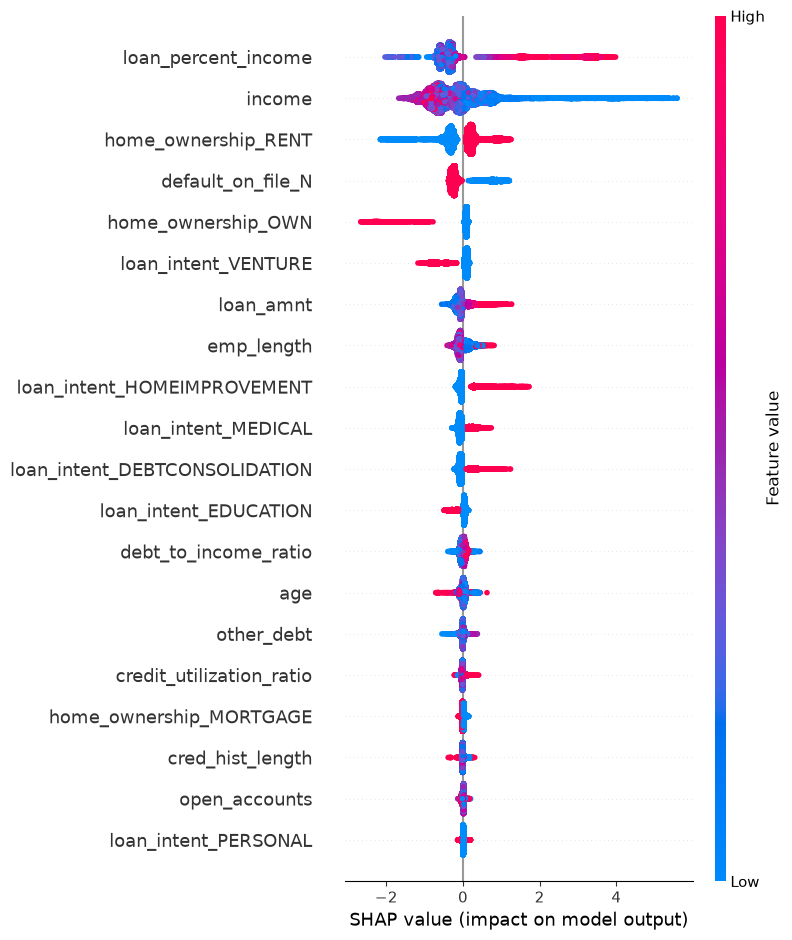

In [8]:
shap.summary_plot(shap_values, X_transformed_df, show=False)

## Top features by SHAP (mean |SHAP value|)

The plan asks for the 3-5 most important features - ranked here by mean absolute SHAP
value across all rows, which is what the summary plot above sorts by.

In [9]:
import numpy as np

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=transformed_names)
top_features = mean_abs_shap.sort_values(ascending=False).head(5)
top_features

loan_percent_income    0.702145
income                 0.593516
home_ownership_RENT    0.381279
default_on_file_N      0.347801
home_ownership_OWN     0.236994
dtype: float32

## Cross-check against session 8's noise-column finding

Session 8's leakage scan found `past_delinquencies`, `open_accounts` and
`credit_utilization_ratio` statistically indistinguishable from the target (single-feature
AUC 0.5004, 0.4980, 0.5051 - see `docs/MEMORY.md`, 2026-09-12 entry). If SHAP assigned
these columns high importance, that would mean the model is confidently using pure noise -
worth knowing before trusting the summary plot above at face value.

In [10]:
noise_columns = ["past_delinquencies", "open_accounts", "credit_utilization_ratio"]
noise_importance = mean_abs_shap.reindex(noise_columns)
print("mean |SHAP| for session 8's noise columns (top feature was "
      f"{mean_abs_shap.max():.4f}, {mean_abs_shap.idxmax()}):")
print(noise_importance)

noise_rank = mean_abs_shap.rank(ascending=False)
print()
print("their rank out of", len(mean_abs_shap), "transformed features:")
print(noise_rank.reindex(noise_columns))

mean |SHAP| for session 8's noise columns (top feature was 0.7021, loan_percent_income):
past_delinquencies          0.005561
open_accounts               0.019358
credit_utilization_ratio    0.031893
dtype: float32

their rank out of 35 transformed features:
past_delinquencies          23.0
open_accounts               19.0
credit_utilization_ratio    16.0
dtype: float64


## Force plot - one specific application

Session 8/9's leakage-scan columns aren't in this model at all (loan_grade,
loan_int_rate excluded by design), so nothing here can attribute a decision to them.

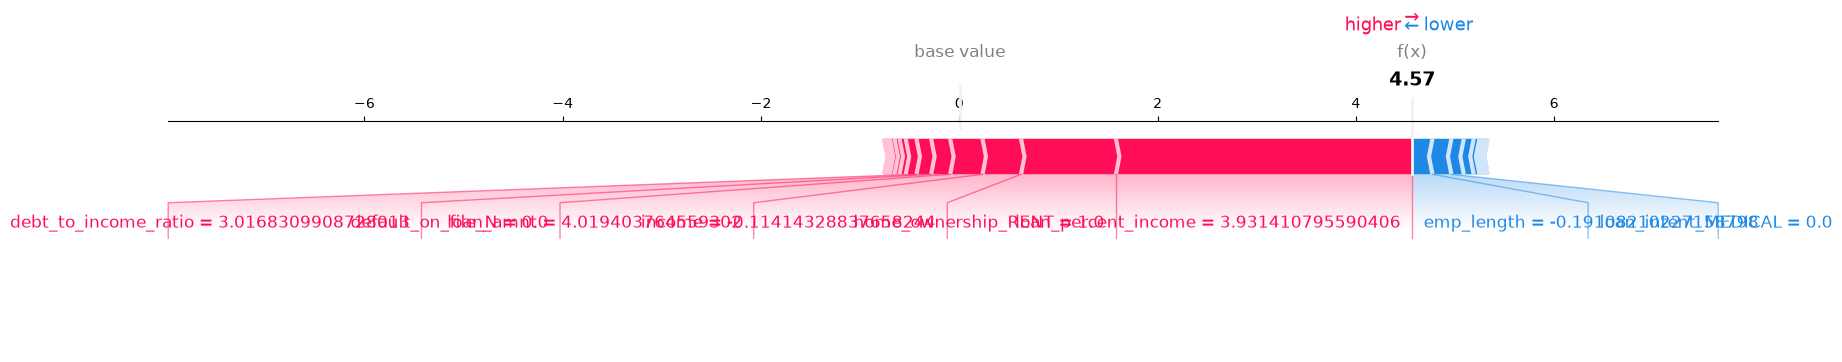

In [11]:
sample_idx = 0
shap.force_plot(
    explainer.expected_value, shap_values[sample_idx], X_transformed_df.iloc[sample_idx],
    matplotlib=True, show=False,
)

## Save both bundles

`preprocessor` is the fitted `ColumnTransformer` itself (per the plan: preprocessor is
literally this ColumnTransformer), not the whole `Pipeline` - `app.py` needs to call
`preprocessor.transform(raw_input)` then `model.predict_proba(...)` as two explicit
steps, matching how `CLAUDE.md`'s conventions describe the bundle being used.
`feature_names` is the **raw** (pre-one-hot) column list, since that's what the session
13 Streamlit form collects from the user - not the expanded post-transform names used
for SHAP above.

In [12]:
import os
os.makedirs("../models", exist_ok=True)

bundle_paths = {
    "at_application": "../models/at_application_model.pkl",
    "portfolio": "../models/portfolio_risk_model.pkl",
}

for feature_set, path in bundle_paths.items():
    pipeline = pipelines[feature_set]["pipeline"]
    cv = cv_metrics[feature_set]
    bundle = {
        "model": pipeline.named_steps["classifier"],
        "preprocessor": pipeline.named_steps["preprocessor"],
        "feature_names": pipelines[feature_set]["feature_names"],
        "trained_at": datetime.now(timezone.utc).isoformat(),
        "trained_on_n_rows": pipelines[feature_set]["n_rows_fit"],
        "metrics": {
            # 5-fold StratifiedKFold(shuffle=True) mean, computed above on the full
            # 32,581-row historical dataset - NOT the session 10/11 single-split holdout
            # number, and NOT the retracted unshuffled cv=5 result from session 10's
            # first (wrong) CV attempt. A CV mean is used, not the holdout figure,
            # because portfolio never had a CV number before this notebook and using a
            # holdout number for one feature set and a CV number for the other would be
            # an inconsistency, not a choice - see CLAUDE.md.
            "roc_auc": cv["roc_auc_mean"],
            "pr_auc": cv["pr_auc_mean"],
            "roc_auc_std": cv["roc_auc_std"],
            "pr_auc_std": cv["pr_auc_std"],
            "holdout_roc_auc": PINNED_METRICS[feature_set]["roc_auc"],
            "holdout_pr_auc": PINNED_METRICS[feature_set]["pr_auc"],
            "method": (
                "5-fold StratifiedKFold(shuffle=True, random_state=42) cross-validation "
                "on the full historical dataset (ml_features, data_source='historical'), "
                "computed in notebooks/05_explainability_and_bundles.ipynb. "
                "holdout_roc_auc/holdout_pr_auc are the session 10-11 single-split "
                "numbers, kept for cross-reference only - not what this bundle reports "
                "as its primary metric."
            ),
        },
    }
    validate_bundle(bundle, expected_n_rows=independent_count)
    joblib.dump(bundle, path)
    print(f"saved {path} ({os.path.getsize(path):,} bytes)")

saved ../models/at_application_model.pkl (501,098 bytes)
saved ../models/portfolio_risk_model.pkl (480,690 bytes)


## Verify: load each bundle back and confirm it predicts

Not just "the file was written" - actually load it in a fresh-looking call and run a
prediction through preprocessor.transform -> model.predict_proba, the same two steps
app.py will use.

In [13]:
for feature_set, path in bundle_paths.items():
    loaded = joblib.load(path)
    validate_bundle(loaded)

    sample = df[loaded["feature_names"]].iloc[[0]]
    transformed = loaded["preprocessor"].transform(sample)
    proba = loaded["model"].predict_proba(transformed)[0, 1]

    print(f"{feature_set:15} loaded OK | trained_at={loaded['trained_at']} | "
          f"sample P(default)={proba:.4f} | metrics={loaded['metrics']}")

at_application  loaded OK | trained_at=2026-09-15T09:51:39.089380+00:00 | sample P(default)=0.9897 | metrics={'roc_auc': np.float64(0.8928061178331552), 'pr_auc': np.float64(0.803165732838792), 'roc_auc_std': np.float64(0.004485370506308223), 'pr_auc_std': np.float64(0.009032157646875935), 'holdout_roc_auc': 0.890672, 'holdout_pr_auc': 0.805474, 'method': "5-fold StratifiedKFold(shuffle=True, random_state=42) cross-validation on the full historical dataset (ml_features, data_source='historical'), computed in notebooks/05_explainability_and_bundles.ipynb. holdout_roc_auc/holdout_pr_auc are the session 10-11 single-split numbers, kept for cross-reference only - not what this bundle reports as its primary metric."}
portfolio       loaded OK | trained_at=2026-09-15T09:51:39.098683+00:00 | sample P(default)=0.9946 | metrics={'roc_auc': np.float64(0.9370162216797733), 'pr_auc': np.float64(0.8858479298762646), 'roc_auc_std': np.float64(0.0034609255776619904), 'pr_auc_std': np.float64(0.006515